# 01 青空文庫 — データ取得・前処理・Word2Vec学習

**このノートブックの目的**

1. 青空文庫から孤独関連テキストを収集する
2. MeCab（fugashi）で形態素解析・トークナイズする
3. Word2Vecモデルを学習する
4. 孤独関連語の意味空間を可視化する

**分析の問い（Phase 1）**
- 「孤独」「孤立」「孤高」はどんな語と共起しているか？
- 時代（明治 / 大正 / 昭和）で意味空間は変わるか？
- Loneliness / Isolation / Solitude の方向ベクトルはデータから確認できるか？

---
> **注意**：青空文庫のテキストは著作権切れ作品が中心（概ね没後70年）。
> 明治〜昭和中期が主なカバー範囲になる。

---
## セッションが切れた場合の再開手順
1. 「ランタイム → すべてのセルを実行」で上から流し直す
2. ダウンロード済みの場合はparquetから読み込むのでスキップされる
3. Google Driveのデータは保持されるので再ダウンロード不要

## 0-A. Google Driveのマウント
データをGoogle Driveに保存することでセッションが切れてもデータが消えない。

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# データ保存先をGoogle Driveに設定
DATA_DIR = Path('/content/drive/MyDrive/loneliness-research-data')
RAW_DIR = DATA_DIR / 'raw' / 'aozora'
PROCESSED_DIR = DATA_DIR / 'processed' / 'aozora'
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Google Drive マウント完了')
print(f'データ保存先: {DATA_DIR}')

Mounted at /content/drive
Google Drive マウント完了
データ保存先: /content/drive/MyDrive/loneliness-research-data


## 0-B. 環境セットアップ

In [2]:
# ライブラリのインストール（Colab用）
!pip install fugashi unidic-lite gensim umap-learn japanize-matplotlib jaconv -q
print('インストール完了')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 21.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 54.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.5 MB/s eta 0:00:00
インストール完了


In [3]:
import os
import re
import gc
import time
import zipfile
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns

import fugashi
import jaconv
from gensim.models import Word2Vec

# 再現性のためシードを固定
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('セットアップ完了')
print(f'  データ保存先: {RAW_DIR}')

セットアップ完了
  データ保存先: /content/drive/MyDrive/loneliness-research-data/raw/aozora


---
## 1. 青空文庫からテキストを取得する

In [4]:
# 青空文庫の作品リスト（CSV）を取得する
CATALOG_URL = 'https://www.aozora.gr.jp/index_pages/list_person_all_extended_utf8.zip'
CATALOG_ZIP = RAW_DIR / 'catalog.zip'
CATALOG_CSV = RAW_DIR / 'list_person_all_extended_utf8.csv'

if not CATALOG_CSV.exists():
    print('作品リストをダウンロード中...')
    urllib.request.urlretrieve(CATALOG_URL, CATALOG_ZIP)
    with zipfile.ZipFile(CATALOG_ZIP, 'r') as zf:
        zf.extractall(RAW_DIR)
    print('完了')
else:
    print('作品リストは取得済み')

df_catalog = pd.read_csv(CATALOG_CSV, encoding='utf-8')
print(f'総作品数: {len(df_catalog):,}')

作品リストは取得済み
総作品数: 19,456


In [5]:
# 時代ラベルを付与する
def assign_era(birth_date_str):
    """生年月日から時代ラベルを返す"""
    try:
        year = int(str(birth_date_str)[:4])
        if year < 1868:
            return '江戸以前'
        elif year < 1900:
            return '明治'
        elif year < 1912:
            return '明治後期〜大正'
        elif year < 1926:
            return '大正〜昭和初期'
        elif year < 1945:
            return '昭和戦前'
        else:
            return '昭和戦後以降'
    except:
        return '不明'

df_catalog['era'] = df_catalog['生年月日'].apply(assign_era)
print(df_catalog['era'].value_counts())

era
明治         12459
明治後期〜大正     3597
江戸以前        1970
大正〜昭和初期      665
不明           398
昭和戦後以降       231
昭和戦前         136
Name: count, dtype: int64


In [6]:
# カラム名を確定版で設定
TEXT_URL_COL = 'テキストファイルURL'
TITLE_COL = '作品名'
AUTHOR_COL = '姓'

# テキストURLがあり、江戸以前と不明を除いた作品に絞る
df_target = df_catalog[
    df_catalog[TEXT_URL_COL].notna() &
    (~df_catalog['era'].isin(['不明', '江戸以前']))
].copy()

print(f'対象作品数: {len(df_target):,}')
print(df_target['era'].value_counts())

対象作品数: 16,863
era
明治         12445
明治後期〜大正     3579
大正〜昭和初期      651
昭和戦後以降       114
昭和戦前          74
Name: count, dtype: int64


In [7]:
# テキストをダウンロード・クリーニングする関数
def download_aozora_text(url, save_path):
    try:
        tmp_zip = str(save_path) + '.zip'
        urllib.request.urlretrieve(url, tmp_zip)
        with zipfile.ZipFile(tmp_zip, 'r') as zf:
            txt_files = [f for f in zf.namelist() if f.endswith('.txt')]
            if not txt_files:
                return None
            with zf.open(txt_files[0]) as f:
                try:
                    content = f.read().decode('shift-jis')
                except:
                    content = f.read().decode('utf-8', errors='ignore')
        os.remove(tmp_zip)
        return content
    except Exception as e:
        print(f'  エラー: {e}')
        return None


def clean_aozora_text(text):
    if text is None:
        return ''
    if '-------' in text:
        text = text.split('-------')[-1]
    text = re.sub(r'《[^》]*》', '', text)
    text = re.sub(r'［＃[^］]*］', '', text)
    text = re.sub(r'｜', '', text)
    text = jaconv.z2h(text, kana=False, ascii=True, digit=True)
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


print('関数定義完了')

関数定義完了


In [8]:
# 保存済みデータを読み込む（ダウンロード済みの場合はスキップ）
parquet_path = PROCESSED_DIR / 'corpus_full.parquet'

if parquet_path.exists():
    df_corpus_full = pd.read_parquet(parquet_path)
    print(f'保存済みデータを読み込みました: {len(df_corpus_full)}作品')
    print(df_corpus_full['era'].value_counts())
else:
    # 初回のみダウンロード実行（20〜30分かかる）
    ERA_LIMITS = {
        '明治':         200,
        '明治後期〜大正': 200,
        '大正〜昭和初期': 200,
        '昭和戦前':      74,
        '昭和戦後以降':  114,
    }
    df_full = (
        df_target
        .groupby('era', group_keys=False)
        .apply(lambda x: x.sample(
            min(ERA_LIMITS.get(x.name, len(x)), len(x)),
            random_state=RANDOM_SEED
        ), include_groups=False)
    )
    print(f'取得予定: {len(df_full)}作品')

    corpus_full = []
    errors = []
    for i, row in df_full.iterrows():
        url = row[TEXT_URL_COL]
        era = row['era']
        title = row[TITLE_COL]
        author = row[AUTHOR_COL]
        text = download_aozora_text(url, RAW_DIR / f'{i}.txt')
        cleaned = clean_aozora_text(text)
        if cleaned and len(cleaned) > 500:
            corpus_full.append({'text': cleaned, 'era': era, 'title': title, 'author': author})
        else:
            errors.append(title)
        time.sleep(0.3)

    print(f'取得完了: {len(corpus_full)}作品 / スキップ: {len(errors)}作品')
    df_corpus_full = pd.DataFrame(corpus_full)
    df_corpus_full.to_parquet(parquet_path, index=False)
    print('保存完了')

保存済みデータを読み込みました: 694作品
era
明治         192
明治後期〜大正    184
大正〜昭和初期    152
昭和戦後以降     102
昭和戦前        64
Name: count, dtype: int64


---
## 2. 形態素解析・トークナイズ

In [9]:
# 形態素解析の設定
tagger = fugashi.Tagger()
TARGET_POS = {'名詞', '動詞', '形容詞', '副詞'}

def tokenize(text, pos_filter=TARGET_POS):
    sentences = []
    current = []
    for word in tagger(text):
        pos = word.feature.pos1
        surface = word.surface
        if surface in {'。', '！', '？', '\n\n'}:
            if len(current) >= 3:
                sentences.append(current)
            current = []
            continue
        if pos not in pos_filter:
            continue
        try:
            lemma = word.feature.lemma
            token = lemma if (lemma and lemma != '*') else surface
        except:
            token = surface
        if len(token) < 2 or token.isnumeric():
            continue
        current.append(token)
    if len(current) >= 3:
        sentences.append(current)
    return sentences

# 動作確認
test_text = '彼は孤独を感じていた。その孤立した日々の中で、ひとり静かに書き続けた。'
print('テスト結果:')
for sent in tokenize(test_text):
    print(' ', sent)

テスト結果:
  ['孤独', '感ずる', '居る']
  ['孤立', '為る', '日々', '一人', '書く', '続ける']


In [10]:
import pickle

# 全量コーパスで形態素解析（都度保存でメモリ節約）
SENTENCES_PATH = PROCESSED_DIR / 'sentences_full.pkl'
ERA_SENTENCES_PATH = PROCESSED_DIR / 'era_sentences_full.pkl'

if SENTENCES_PATH.exists() and ERA_SENTENCES_PATH.exists():
    print('トークナイズ済みデータを読み込み中...')
    with open(SENTENCES_PATH, 'rb') as f:
        all_sentences_full = pickle.load(f)
    with open(ERA_SENTENCES_PATH, 'rb') as f:
        era_sentences_full = pickle.load(f)
    print(f'読み込み完了: 総文数 {len(all_sentences_full):,}')
else:
    print('トークナイズ開始...')
    all_sentences_full = []
    era_sentences_full = {}

    BATCH_SIZE = 20  # 小さくしてメモリ節約

    for batch_start in range(0, len(df_corpus_full), BATCH_SIZE):
        batch = df_corpus_full.iloc[batch_start:batch_start + BATCH_SIZE]
        for _, row in batch.iterrows():
            # テキストを段落単位に分割して一度に処理する量を減らす
            paragraphs = row['text'].split('\n\n')
            for para in paragraphs:
                if len(para) < 10:
                    continue
                sentences = tokenize(para)
                all_sentences_full.extend(sentences)
                era = row['era']
                if era not in era_sentences_full:
                    era_sentences_full[era] = []
                era_sentences_full[era].extend(sentences)
        gc.collect()
        print(f'  {min(batch_start + BATCH_SIZE, len(df_corpus_full))} / {len(df_corpus_full)}作品処理済み')

    # 処理完了後に保存
    print('保存中...')
    with open(SENTENCES_PATH, 'wb') as f:
        pickle.dump(all_sentences_full, f)
    with open(ERA_SENTENCES_PATH, 'wb') as f:
        pickle.dump(era_sentences_full, f)
    print('保存完了')

print(f'\n総文数: {len(all_sentences_full):,}')
for era, sents in sorted(era_sentences_full.items()):
    print(f'  {era}: {len(sents):,}文')

トークナイズ済みデータを読み込み中...
読み込み完了: 総文数 225,305

総文数: 225,305
  大正〜昭和初期: 27,687文
  明治: 52,077文
  明治後期〜大正: 36,652文
  昭和戦前: 60,059文
  昭和戦後以降: 48,830文


---
## 3. Word2Vecモデルの学習

In [11]:
W2V_PARAMS = dict(
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,
    epochs=10,
    workers=4,
    seed=RANDOM_SEED,
)

print('Word2Vec学習中...')
model = Word2Vec(sentences=all_sentences_full, **W2V_PARAMS)
print(f'語彙数: {len(model.wv):,}')
model.save(str(PROCESSED_DIR / 'w2v_aozora_all.model'))
print('モデル保存完了')

Word2Vec学習中...
語彙数: 35,184
モデル保存完了


In [12]:
# 孤独関連語の類似語を確認
SEED_WORDS = ['孤独', '孤立', '孤高', '寂しい', 'ひとり', '一人']

for word in SEED_WORDS:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=10)
        print(f'\n【{word}】に近い語:')
        for w, score in similar:
            print(f'  {w:10s}  {score:.3f}')
    else:
        print(f'\n【{word}】: 語彙になし')


【孤独】に近い語:
  天涯          0.803
  悲哀          0.788
  憧憬          0.766
  世俗          0.745
  捌け口         0.733
  寂寥          0.731
  生き甲斐        0.730
  反芻          0.727
  罪悪          0.726
  不具          0.722

【孤立】に近い語:
  活力          0.845
  対峙          0.823
  倍増          0.821
  蹂躙          0.820
  相克          0.815
  萌芽          0.812
  分化          0.809
  根強い         0.806
  無援          0.806
  プロテスタント-Protestant  0.805

【孤高】に近い語:
  習癖          0.939
  生育          0.932
  堕する         0.926
  審美          0.925
  プレボ         0.924
  世態          0.921
  陶冶          0.921
  根幹          0.919
  開眼          0.918
  我執          0.918

【寂しい】に近い語:
  恋しい         0.739
  うらぶれる       0.718
  郷愁          0.685
  慰む          0.674
  心細い         0.668
  遣る瀬         0.663
  侘しい         0.662
  無性          0.650
  古里          0.649
  孤独          0.649

【ひとり】: 語彙になし

【一人】に近い語:
  ポリネシア-Polynesia  0.588
  馬番          0.549
  初老          0.533
  男性          0.532
  話し込む        0.504
  飛去          0.5

---
## 4. 孤独語の意味空間を可視化する（UMAP）

In [13]:
# 三分類のSeed語彙
LONELINESS_SEEDS = ['孤独', '寂しい', '悲しい', '虚しい', '空虚', '疎外', '取り残す', '心細い']
ISOLATION_SEEDS  = ['孤立', '断絶', '疎遠', '引きこもる', '排除', '遠ざかる', '孤立無援']
SOLITUDE_SEEDS   = ['孤高', '独り', '静かだ', '自由', '内省', '沈黙', '一人']
CONNECTION_SEEDS = ['友人', '家族', '絆', 'つながる', '仲間', '集う', '愛する']

def filter_vocab(words, model):
    return [w for w in words if w in model.wv]

loneliness_words = filter_vocab(LONELINESS_SEEDS, model)
isolation_words  = filter_vocab(ISOLATION_SEEDS, model)
solitude_words   = filter_vocab(SOLITUDE_SEEDS, model)
connection_words = filter_vocab(CONNECTION_SEEDS, model)

print('可視化対象語数:')
print(f'  Loneliness: {len(loneliness_words)} → {loneliness_words}')
print(f'  Isolation:  {len(isolation_words)} → {isolation_words}')
print(f'  Solitude:   {len(solitude_words)} → {solitude_words}')
print(f'  Connection: {len(connection_words)} → {connection_words}')

可視化対象語数:
  Loneliness: 7 → ['孤独', '寂しい', '悲しい', '空虚', '疎外', '取り残す', '心細い']
  Isolation:  4 → ['孤立', '断絶', '排除', '遠ざかる']
  Solitude:   6 → ['孤高', '独り', '自由', '内省', '沈黙', '一人']
  Connection: 5 → ['友人', '家族', '仲間', '集う', '愛する']


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


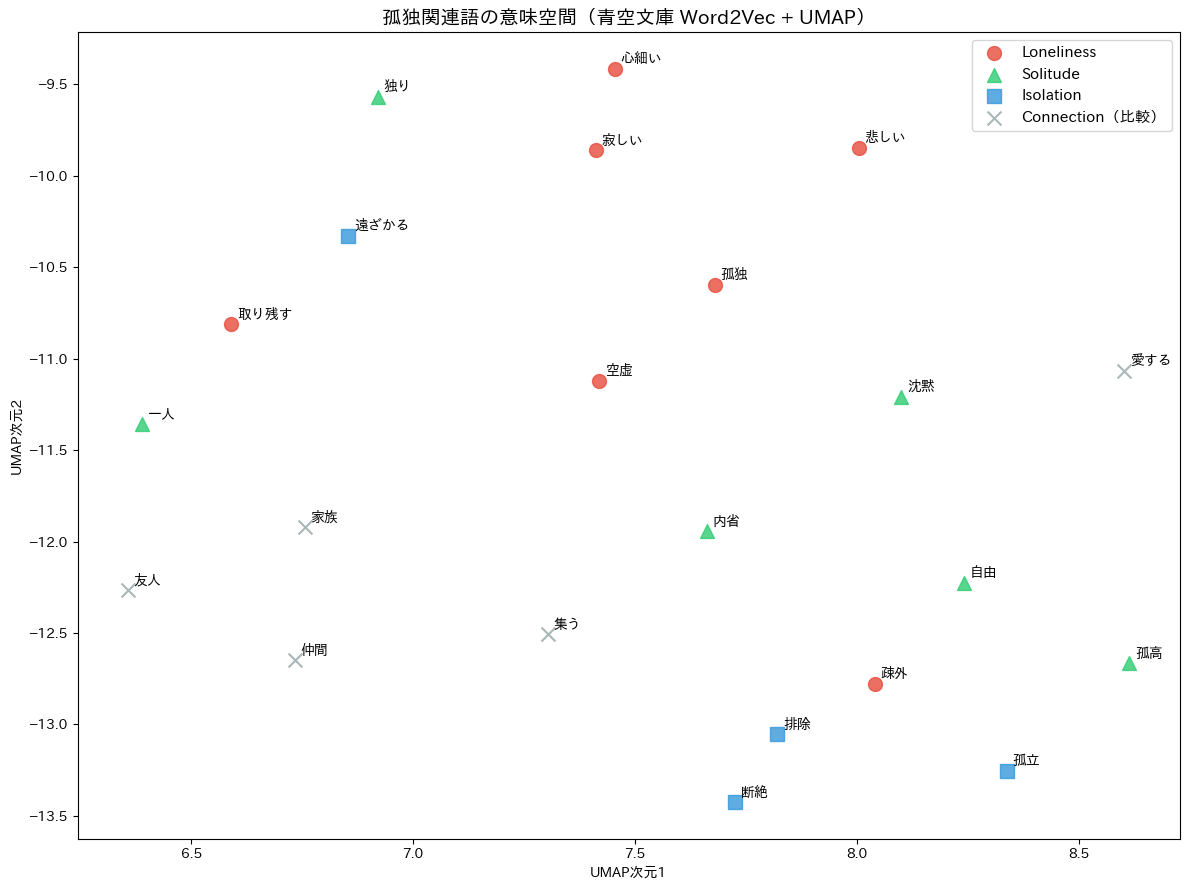

図を保存しました


In [14]:
import umap.umap_ as umap

viz_words = loneliness_words + isolation_words + solitude_words + connection_words
viz_labels = (
    ['Loneliness'] * len(loneliness_words) +
    ['Isolation']  * len(isolation_words) +
    ['Solitude']   * len(solitude_words) +
    ['Connection（比較）'] * len(connection_words)
)

vectors = np.array([model.wv[w] for w in viz_words])

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=min(10, len(viz_words)-1),
    random_state=RANDOM_SEED,
    metric='cosine'
)
embedding = reducer.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(12, 9))
COLORS  = {'Loneliness': '#E74C3C', 'Isolation': '#3498DB', 'Solitude': '#2ECC71', 'Connection（比較）': '#95A5A6'}
MARKERS = {'Loneliness': 'o',       'Isolation': 's',       'Solitude': '^',       'Connection（比較）': 'x'}

for label in set(viz_labels):
    idx = [i for i, l in enumerate(viz_labels) if l == label]
    ax.scatter(embedding[idx, 0], embedding[idx, 1],
               c=COLORS[label], marker=MARKERS[label], s=100, label=label, alpha=0.8)

for i, (word, label) in enumerate(zip(viz_words, viz_labels)):
    ax.annotate(word, (embedding[i, 0], embedding[i, 1]),
                fontsize=10, textcoords='offset points', xytext=(4, 4))

ax.legend(fontsize=11)
ax.set_title('孤独関連語の意味空間（青空文庫 Word2Vec + UMAP）', fontsize=14)
ax.set_xlabel('UMAP次元1')
ax.set_ylabel('UMAP次元2')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'umap_loneliness_words.png', dpi=150)
plt.show()
print('図を保存しました')

---
## 5. 方向ベクトルの試作（Loneliness / Isolation / Solitude 軸）

In [15]:
from numpy.linalg import norm

def make_axis_vector(seed_words, model):
    vecs = [model.wv[w] for w in seed_words if w in model.wv]
    if not vecs:
        return None
    axis = np.mean(vecs, axis=0)
    return axis / norm(axis)

def score_on_axis(word, axis_vector, model):
    if word not in model.wv or axis_vector is None:
        return None
    wv = model.wv[word]
    return float(np.dot(wv, axis_vector) / (norm(wv) * norm(axis_vector)))

axis_loneliness = make_axis_vector(loneliness_words, model)
axis_isolation  = make_axis_vector(isolation_words, model)
axis_solitude   = make_axis_vector(solitude_words, model)

print('軸ベクトル作成完了')
print(f'  Loneliness軸: {len(loneliness_words)}語から')
print(f'  Isolation軸:  {len(isolation_words)}語から')
print(f'  Solitude軸:   {len(solitude_words)}語から')

軸ベクトル作成完了
  Loneliness軸: 7語から
  Isolation軸:  4語から
  Solitude軸:   6語から


In [16]:
# 孤独周辺語を3軸でスコアリング
TARGET_WORDS_FOR_SCORING = [
    '孤独', '孤立', '孤高', '寂しい', '独り', '一人',
    '悲しい', '自由', '静かだ', '断絶', '友人', '家族', '愛する',
    '夜', '部屋', '窓', '海', '空'
]

rows = []
for word in TARGET_WORDS_FOR_SCORING:
    if word not in model.wv:
        continue
    rows.append({
        'word': word,
        'Loneliness': score_on_axis(word, axis_loneliness, model),
        'Isolation':  score_on_axis(word, axis_isolation, model),
        'Solitude':   score_on_axis(word, axis_solitude, model),
    })

df_scores = pd.DataFrame(rows).set_index('word')
print(df_scores.round(3).to_string())

      Loneliness  Isolation  Solitude
word                                 
孤独         0.862      0.597     0.674
孤立         0.619      0.893     0.627
孤高         0.635      0.772     0.714
寂しい        0.805      0.467     0.542
独り         0.583      0.468     0.666
一人         0.412      0.349     0.583
悲しい        0.786      0.469     0.542
自由         0.354      0.383     0.643
断絶         0.497      0.761     0.668
友人         0.379      0.292     0.455
家族         0.549      0.446     0.492
愛する        0.575      0.481     0.580
部屋         0.324      0.274     0.345


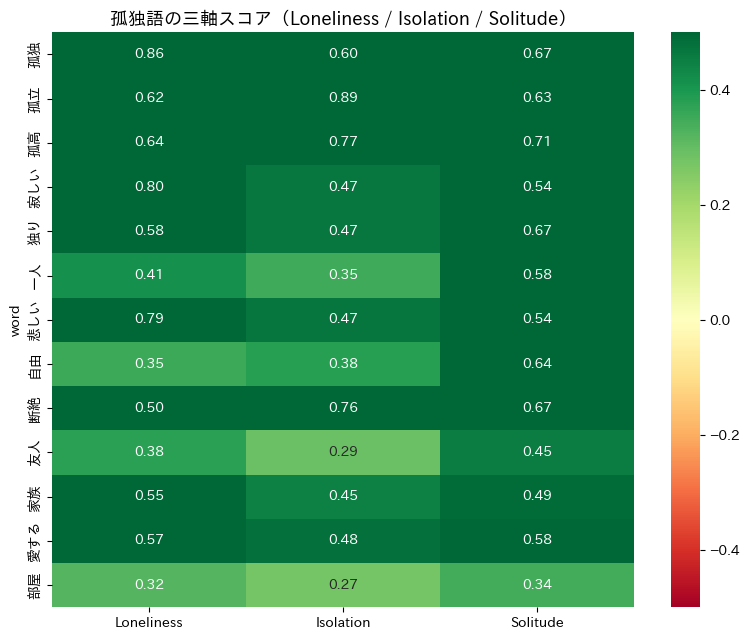

In [17]:
# ヒートマップで可視化
fig, ax = plt.subplots(figsize=(8, max(4, len(df_scores) * 0.5)))
sns.heatmap(df_scores, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title('孤独語の三軸スコア（Loneliness / Isolation / Solitude）', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'axis_scores_heatmap.png', dpi=150)
plt.show()

---
## 6. 時代別比較

In [18]:
# 時代別モデルを学習
era_models = {}

for era, sents in sorted(era_sentences_full.items()):
    if len(sents) < 100:
        print(f'[{era}] データ不足でスキップ ({len(sents)}文)')
        continue
    print(f'[{era}] 学習中... ({len(sents):,}文)', end='')
    m = Word2Vec(sentences=sents, **W2V_PARAMS)
    era_models[era] = m
    print(f' 完了（語彙数: {len(m.wv):,}）')

print(f'\n学習済み時代: {list(era_models.keys())}')

[大正〜昭和初期] 学習中... (27,687文) 完了（語彙数: 9,780）
[明治] 学習中... (52,077文) 完了（語彙数: 17,588）
[明治後期〜大正] 学習中... (36,652文) 完了（語彙数: 13,432）
[昭和戦前] 学習中... (60,059文) 完了（語彙数: 12,108）
[昭和戦後以降] 学習中... (48,830文) 完了（語彙数: 13,386）

学習済み時代: ['大正〜昭和初期', '明治', '明治後期〜大正', '昭和戦前', '昭和戦後以降']


In [19]:
# 時代別の「孤独」類似語比較
FOCUS_WORD = '孤独'

for era, m in sorted(era_models.items()):
    if FOCUS_WORD in m.wv:
        similar = m.wv.most_similar(FOCUS_WORD, topn=10)
        print(f'\n【{era}】「{FOCUS_WORD}」に近い語:')
        for w, s in similar:
            print(f'  {w:12s} {s:.3f}')
    else:
        print(f'\n【{era}】「{FOCUS_WORD}」は語彙になし')


【大正〜昭和初期】「孤独」に近い語:
  解放           0.931
  感傷           0.931
  得体           0.930
  感覚           0.926
  悩む           0.921
  運命           0.916
  境遇           0.915
  日常           0.911
  執念           0.911
  引き付ける        0.910

【明治】「孤独」に近い語:
  痛切           0.949
  聡明           0.946
  感傷           0.933
  公子           0.929
  愛着           0.927
  悲哀           0.925
  憧れ           0.925
  執着           0.923
  焦燥           0.921
  誘惑           0.918

【明治後期〜大正】「孤独」に近い語:
  感傷           0.932
  捕らわれる        0.903
  悲しむ          0.891
  良心           0.890
  耐える          0.887
  幸福           0.885
  気力           0.882
  生き甲斐         0.882
  生涯           0.881
  見出だす         0.877

【昭和戦前】「孤独」に近い語:
  苦悩           0.852
  振る舞う         0.847
  妄想           0.845
  屈辱           0.842
  苦痛           0.842
  不潔           0.840
  野心           0.836
  臆病           0.830
  気侭           0.829
  崇高           0.828

【昭和戦後以降】「孤独」に近い語:
  盛る           0.945
  歩哨           0.945
  輝き           0.945
  薔薇色 

3/11 分類語彙表における孤独同一クラスター語出現頻度確認

In [20]:
check = ['憂鬱', '鬱屈', '抑鬱', '煩悶', '憂い', '物憂さ', '虚ろ', 'ひとりぼっち', '孤独感']
for w in check:
    if w in model.wv:
        print(f"{w}: {model.wv.get_vecattr(w, 'count')}回")
    else:
        print(f"{w}: ★語彙外")

憂鬱: 138回
鬱屈: 6回
抑鬱: ★語彙外
煩悶: 31回
憂い: 75回
物憂さ: ★語彙外
虚ろ: ★語彙外
ひとりぼっち: ★語彙外
孤独感: ★語彙外


In [21]:
check_all = [
    # Loneliness現候補
    '寂しい', '寂しさ', '淋しい', '空虚', '虚しい', '心細い',
    # Isolation候補
    '孤立', '断絶', '孤絶', '隔絶', '疎遠', '絶縁', '無縁', '排除', '追放','独身','単身','身一つ','未婚','ひとり身','天涯孤独','四面楚歌','孤立無縁',
    # Solitude候補
    '孤高', '隠遁', '独居', '静寂', '沈黙', '内省','独身貴族',
]
for w in check_all:
    if w in model.wv:
        print(f"{w}: {model.wv.get_vecattr(w, 'count')}回")
    else:
        print(f"{w}: ★語彙外")

寂しい: 560回
寂しさ: ★語彙外
淋しい: ★語彙外
空虚: 55回
虚しい: ★語彙外
心細い: 90回
孤立: 40回
断絶: 6回
孤絶: ★語彙外
隔絶: 4回
疎遠: ★語彙外
絶縁: 9回
無縁: ★語彙外
排除: 17回
追放: 40回
独身: 87回
単身: 10回
身一つ: ★語彙外
未婚: 12回
ひとり身: ★語彙外
天涯孤独: ★語彙外
四面楚歌: ★語彙外
孤立無縁: ★語彙外
孤高: 4回
隠遁: 6回
独居: ★語彙外
静寂: 43回
沈黙: 200回
内省: 13回
独身貴族: ★語彙外


In [22]:
for word in ['沈黙', '静寂', '孤高', '隠遁']:
    if word in model.wv:
        print(f"\n{word}の近傍語:")
        for w, s in model.wv.most_similar(word, topn=10):
            print(f"  {w}: {s:.3f}")


沈黙の近傍語:
  余韻: 0.666
  爆笑: 0.660
  残留: 0.649
  静寂: 0.647
  息遣い: 0.635
  黙祷: 0.631
  心行く: 0.630
  交わし合う: 0.618
  タシロ: 0.616
  呪文: 0.613

静寂の近傍語:
  怒号: 0.845
  銃声: 0.841
  静けさ: 0.824
  しいん: 0.822
  海鳴り: 0.821
  劈く: 0.817
  湛える: 0.816
  騒めき: 0.815
  雷鳴: 0.815
  鼓膜: 0.811

孤高の近傍語:
  習癖: 0.939
  生育: 0.932
  堕する: 0.926
  審美: 0.925
  プレボ: 0.924
  世態: 0.921
  陶冶: 0.921
  根幹: 0.919
  開眼: 0.918
  我執: 0.918

隠遁の近傍語:
  安逸: 0.911
  追慕: 0.898
  放縦: 0.897
  流れ者: 0.893
  自認: 0.890
  愛妻: 0.890
  族長: 0.890
  色欲: 0.889
  古馴染み: 0.887
  世捨て: 0.885


In [23]:
# Isolation追加候補の頻度確認
check_isolation = [
    '流刑', '島流し', '配流',    # 強制的排除の文語表現
    '勘当', '破門',              # 関係の一方的切断
    '村八分',                    # 社会的排除の慣用表現
    '疎んじる', '疎む',          # 関係の希薄化
    '遠ざける', '遠ざかる',      # 距離化
    '仲間外れ', '除け者',        # 排除の口語表現
]
for w in check_isolation:
    if w in model.wv:
        print(f"{w}: {model.wv.get_vecattr(w, 'count')}回")
    else:
        print(f"{w}: ★語彙外")

流刑: 20回
島流し: ★語彙外
配流: 3回
勘当: 23回
破門: ★語彙外
村八分: ★語彙外
疎んじる: ★語彙外
疎む: 24回
遠ざける: 23回
遠ざかる: 88回
仲間外れ: ★語彙外
除け者: 4回


In [24]:
for word in ['孤立', '追放', '排除', '絶縁', '疎む', '勘当', '遠ざかる']:
    if word in model.wv:
        print(f"\n{word}の近傍語:")
        for w, s in model.wv.most_similar(word, topn=10):
            print(f"  {w}: {s:.3f}")


孤立の近傍語:
  活力: 0.845
  対峙: 0.823
  倍増: 0.821
  蹂躙: 0.820
  相克: 0.815
  萌芽: 0.812
  分化: 0.809
  根強い: 0.806
  無援: 0.806
  プロテスタント-Protestant: 0.805

追放の近傍語:
  奪取: 0.830
  死罪: 0.809
  カダ: 0.794
  内妻: 0.780
  村長: 0.778
  良人: 0.771
  改易: 0.769
  私欲: 0.768
  斷絶: 0.768
  出奔: 0.766

排除の近傍語:
  没入: 0.907
  包括: 0.905
  テンニース: 0.899
  適応: 0.896
  行使: 0.895
  ファッショ-fascio: 0.893
  エンゲルス-Engels: 0.892
  世襲: 0.889
  体様: 0.889
  父権: 0.888

絶縁の近傍語:
  言辞: 0.878
  素行: 0.868
  抑留: 0.868
  黙認: 0.865
  親譲り: 0.863
  士道: 0.862
  慰楽: 0.861
  豪胆: 0.861
  世捨て: 0.861
  露国: 0.861

疎むの近傍語:
  貧苦: 0.849
  定業: 0.848
  文無し: 0.845
  縁付く: 0.843
  心願: 0.836
  天道: 0.835
  ヒラオ: 0.832
  妬む: 0.832
  内方: 0.832
  弔う: 0.831

勘当の近傍語:
  淫奔: 0.801
  施し: 0.798
  外聞: 0.796
  捨て置く: 0.791
  仕甲斐: 0.787
  免職: 0.783
  縁付く: 0.782
  落籍す: 0.780
  焼け死ぬ: 0.779
  会わす: 0.779

遠ざかるの近傍語:
  遠退く: 0.811
  狭める: 0.801
  踏み締める: 0.780
  棒立ち: 0.767
  ぼやける: 0.761
  揺られる: 0.761
  くねくね: 0.758
  突き進む: 0.758
  とろん: 0.757
  舞い下りる: 0.756


---
## メモ・気づき

（このセルに分析中の気づき・疑問点を随時記録する）

-
-

## 次のステップ

- [ ] BCCWJが届いたら同じパイプラインを適用
- [ ] Sentence-BERT に切り替えて文レベル分析
- [ ] 孤独語を含む文の抽出・クラスタリング